# Retail Credit PD Scorecard — End-to-End Walkthrough

Builds a Probability-of-Default (PD) scorecard from 10 linked source tables
(application, behavioral, bureau, loan, transaction, repayment, collateral,
collection, NPA/default flags, master modelling table) following the standard
retail credit-risk scorecard methodology:

`Data Sourcing -> Target/Vintage -> Sampling -> Data Prep -> Segmentation ->
WOE/IV -> Variable Reduction -> Logistic Regression -> Scorecard Calibration -> Validation`

Run `python run_pipeline.py` from the repo root first (or step through the
cells below, which call the same `src/*.py` modules directly) to generate the
artifacts this notebook visualizes.

In [1]:
import sys, os
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import config as cfg

sns.set_style('whitegrid')
os.chdir('..')  # run from repo root so relative paths in config resolve

## 1. Data Sourcing & Merge Quality Audit

In [2]:
qc = pd.read_csv('reports/01_data_quality_audit.csv')
qc

,table,rows,cols,dup_rows,dup_customer_id,null_cells
0,application,1000,12,0,0,0
1,behavioral,1000,7,0,0,0
2,bureau,1000,17,0,0,0
3,loan,1000,11,0,0,0
4,transaction,1000,13,0,0,0
5,repayment,1000,14,0,0,0
6,collateral,1000,10,0,0,3556
7,collection,1000,12,0,0,1760
8,npa,1000,5,0,0,0
9,master,1000,40,0,0,1757


## 2. Vintage Analysis

Quarterly bad-rate by disbursal vintage — used to justify the OOT cut-off.

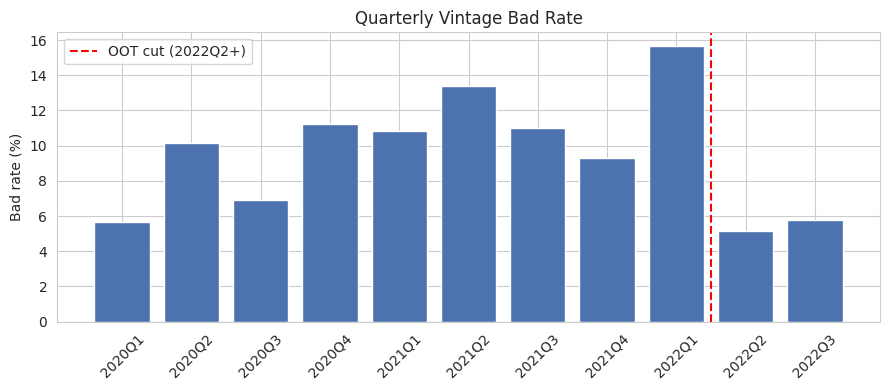

,Vintage_Quarter,accounts,bads,bad_rate
0,2020Q1,106,6,5.66
1,2020Q2,79,8,10.13
2,2020Q3,101,7,6.93
3,2020Q4,107,12,11.21
4,2021Q1,83,9,10.84
5,2021Q2,97,13,13.40
6,2021Q3,82,9,10.98
7,2021Q4,97,9,9.28
8,2022Q1,83,13,15.66
9,2022Q2,78,4,5.13


In [3]:
vintage = pd.read_csv('reports/02_vintage_analysis.csv')
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(vintage['Vintage_Quarter'], vintage['bad_rate'], color='#4C72B0')
ax.axvline(x=8.5, color='red', linestyle='--', label='OOT cut (2022Q2+)')
ax.set_ylabel('Bad rate (%)'); ax.set_title('Quarterly Vintage Bad Rate'); ax.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
vintage

## 3. Missing Value Treatment

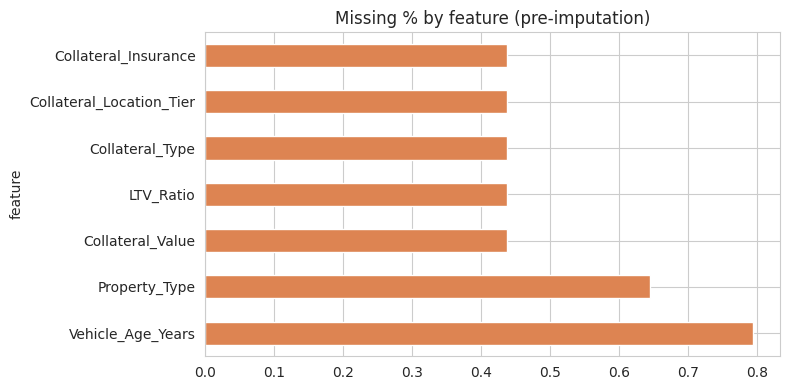

In [4]:
miss = pd.read_csv('reports/03_missing_value_report.csv')
miss[miss.missing_pct > 0].plot.barh(x='feature', y='missing_pct', figsize=(8,4), legend=False, color='#DD8452')
plt.title('Missing % by feature (pre-imputation)'); plt.tight_layout(); plt.show()

## 4. Information Value (IV) Ranking & Business Review

See `notebooks/00_methodology_notes.md` for why the highest-IV variables were excluded rather than blindly kept.

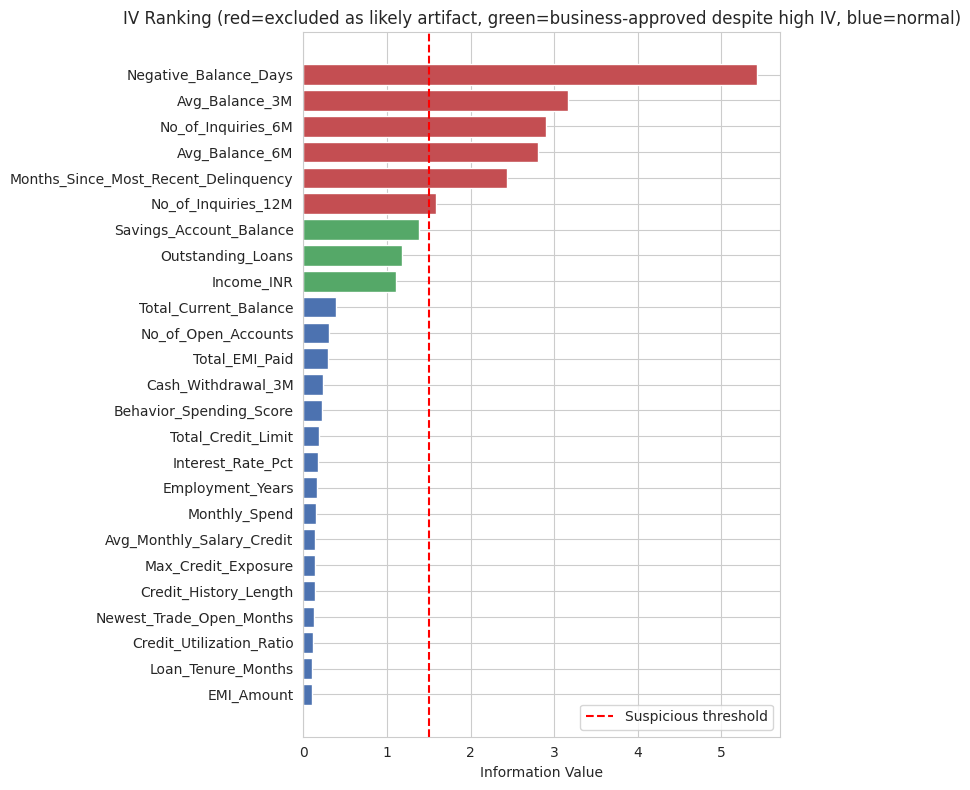

In [5]:
iv = pd.read_csv('reports/04_iv_summary.csv').sort_values('iv', ascending=False)
fig, ax = plt.subplots(figsize=(8,8))
colors = ['#C44E52' if v > cfg.IV_SUSPICIOUS_THRESHOLD else ('#55A868' if f in cfg.BUSINESS_APPROVED_HIGH_IV_VARS else '#4C72B0')
          for f, v in zip(iv.feature, iv.iv)]
ax.barh(iv.feature.head(25), iv.iv.head(25), color=colors[:25])
ax.invert_yaxis()
ax.axvline(cfg.IV_SUSPICIOUS_THRESHOLD, color='red', linestyle='--', label='Suspicious threshold')
ax.set_xlabel('Information Value'); ax.set_title('IV Ranking (red=excluded as likely artifact, green=business-approved despite high IV, blue=normal)')
ax.legend(); plt.tight_layout(); plt.show()

## 5. K-Means Risk Segmentation

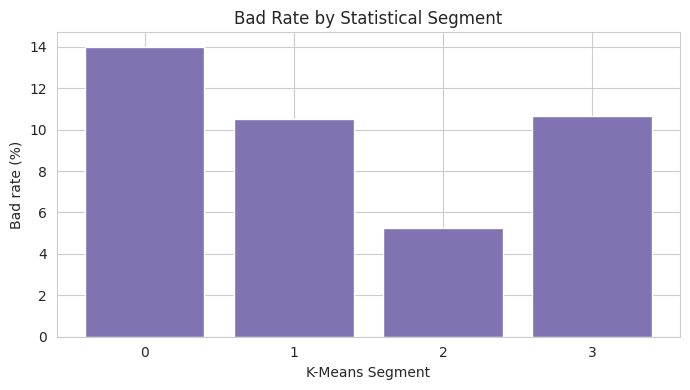

,Segment,accounts,bad_rate,avg_income,avg_credit_limit
0,0,150,14.00,1.166888e+06,5.938305e+05
1,1,152,10.53,1.302238e+06,1.713694e+06
2,2,172,5.23,1.447005e+06,2.171310e+06
3,3,150,10.67,9.968496e+05,1.327362e+06


In [6]:
seg = pd.read_csv('reports/06_kmeans_segment_profile.csv')
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(seg.Segment.astype(str), seg.bad_rate, color='#8172B2')
ax.set_xlabel('K-Means Segment'); ax.set_ylabel('Bad rate (%)'); ax.set_title('Bad Rate by Statistical Segment')
plt.tight_layout(); plt.show()
seg

## 6. Logistic Regression Coefficients (WOE scale)

Every coefficient should be negative: higher WOE (safer bin) -> lower log-odds of default.

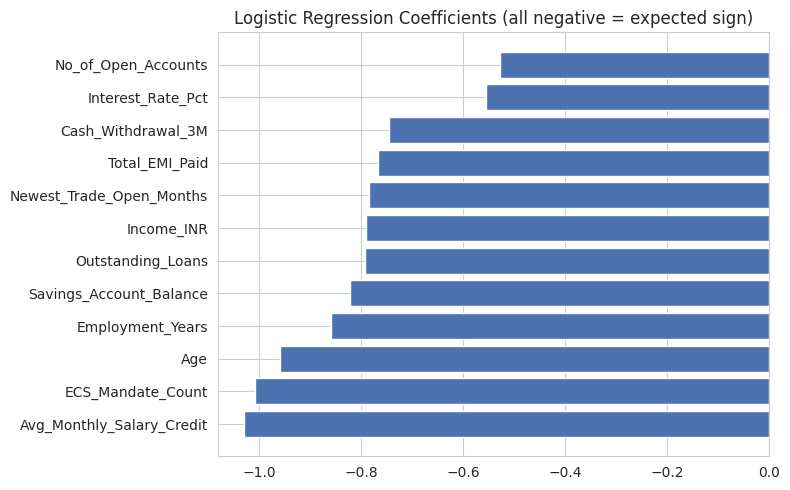

In [7]:
coefs = pd.read_csv('reports/07_logistic_coefficients.csv').sort_values('coefficient')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(coefs.feature, coefs.coefficient, color='#4C72B0')
ax.set_title('Logistic Regression Coefficients (all negative = expected sign)')
plt.tight_layout(); plt.show()

## 7. Scorecard Points Table

In [8]:
pts = pd.read_csv('reports/08_scorecard_points_table.csv')
pts.head(20)

,feature,bin,count,woe,points
0,Savings_Account_Balance,0,101,-0.983153,22.1
1,Savings_Account_Balance,1,66,-1.644752,6.4
2,Savings_Account_Balance,2,457,1.178892,73.3
3,Savings_Account_Balance,3,0,0.000000,45.4
4,Savings_Account_Balance,4,0,0.000000,45.4
5,Income_INR,0,153,-1.265087,16.5
6,Income_INR,1,471,0.964876,67.4
7,Income_INR,2,0,0.000000,45.4
8,Income_INR,3,0,0.000000,45.4
9,Outstanding_Loans,0,300,1.392945,77.3


## 8. Score Distribution & Rank Ordering

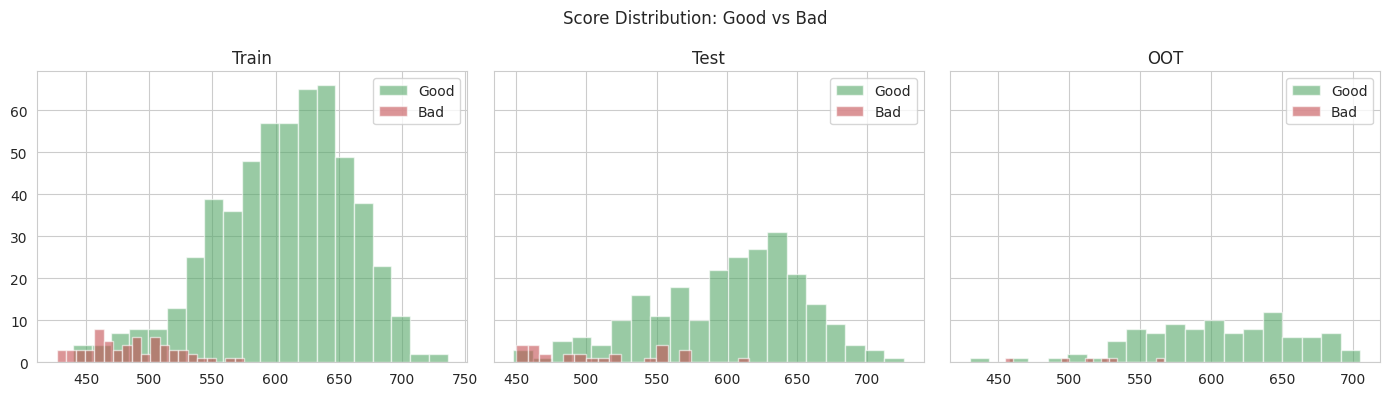

In [9]:
train_s = pd.read_csv('data/processed/train_scored.csv')
test_s = pd.read_csv('data/processed/test_scored.csv')
oot_s = pd.read_csv('data/processed/oot_scored.csv')

fig, axes = plt.subplots(1, 3, figsize=(14,4), sharey=True)
for ax, (name, d) in zip(axes, [('Train', train_s), ('Test', test_s), ('OOT', oot_s)]):
    ax.hist(d.loc[d.Default==0,'Score'], bins=20, alpha=0.6, label='Good', color='#55A868')
    ax.hist(d.loc[d.Default==1,'Score'], bins=20, alpha=0.6, label='Bad', color='#C44E52')
    ax.set_title(name); ax.legend()
plt.suptitle('Score Distribution: Good vs Bad'); plt.tight_layout(); plt.show()

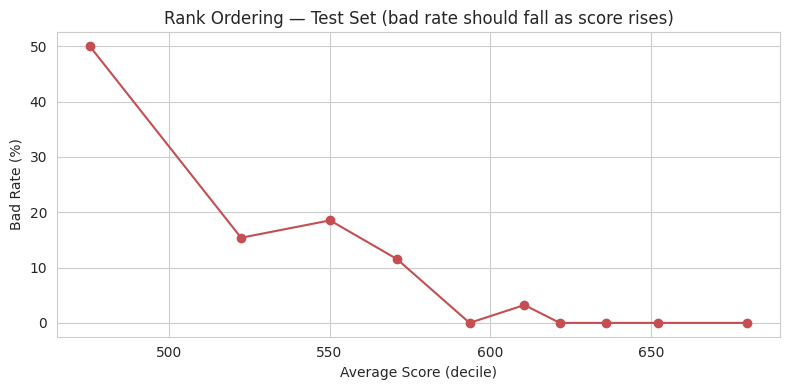

,Decile,accounts,bads,avg_score,bad_rate_pct,cum_bads_pct
0,0,28,14,475.357143,50.00,51.9
1,1,26,4,522.461538,15.38,66.7
2,2,27,5,550.148148,18.52,85.2
3,3,26,3,570.961538,11.54,96.3
4,4,27,0,593.592593,0.00,96.3
5,5,31,1,610.677419,3.23,100.0
6,6,22,0,621.681818,0.00,100.0
7,7,29,0,635.965517,0.00,100.0
8,8,26,0,652.192308,0.00,100.0
9,9,26,0,680.000000,0.00,100.0


In [10]:
decile = pd.read_csv('reports/10_decile_rank_order_test.csv')
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(decile.avg_score, decile.bad_rate_pct, marker='o', color='#C44E52')
ax.set_xlabel('Average Score (decile)'); ax.set_ylabel('Bad Rate (%)')
ax.set_title('Rank Ordering — Test Set (bad rate should fall as score rises)')
plt.tight_layout(); plt.show()
decile

## 9. ROC Curve & Validation Summary

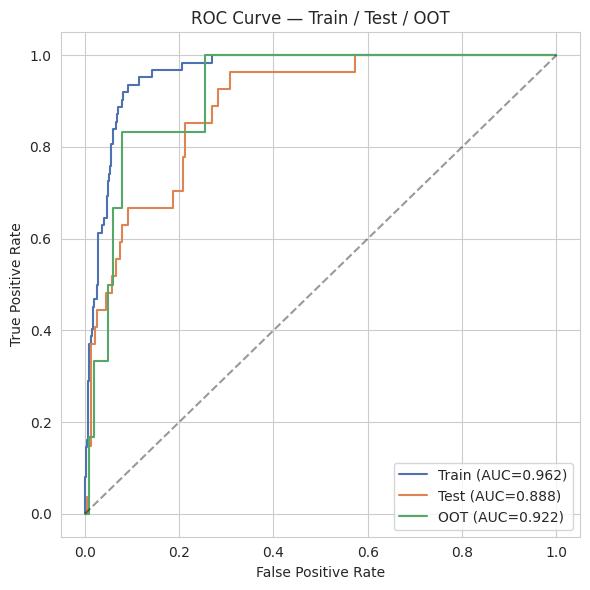

,AUC,Gini,KS,n,bad_rate
train,0.961859,0.923717,84.295718,624.0,0.099359
test,0.888120,0.776241,65.590902,268.0,0.100746
oot,0.921569,0.843137,75.490196,108.0,0.055556


In [11]:
from sklearn.metrics import roc_curve

perf = pd.read_csv('reports/09_model_performance_summary.csv', index_col=0)
fig, ax = plt.subplots(figsize=(6,6))
for name, d, color in [('Train', train_s, '#4C72B0'), ('Test', test_s, '#DD8452'), ('OOT', oot_s, '#55A868')]:
    fpr, tpr, _ = roc_curve(d.Default, d.PD)
    auc = perf.loc[name.lower(), 'AUC']
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Train / Test / OOT'); ax.legend()
plt.tight_layout(); plt.show()
perf

## 10. SHAP Explainability — Challenger Model Cross-Check

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


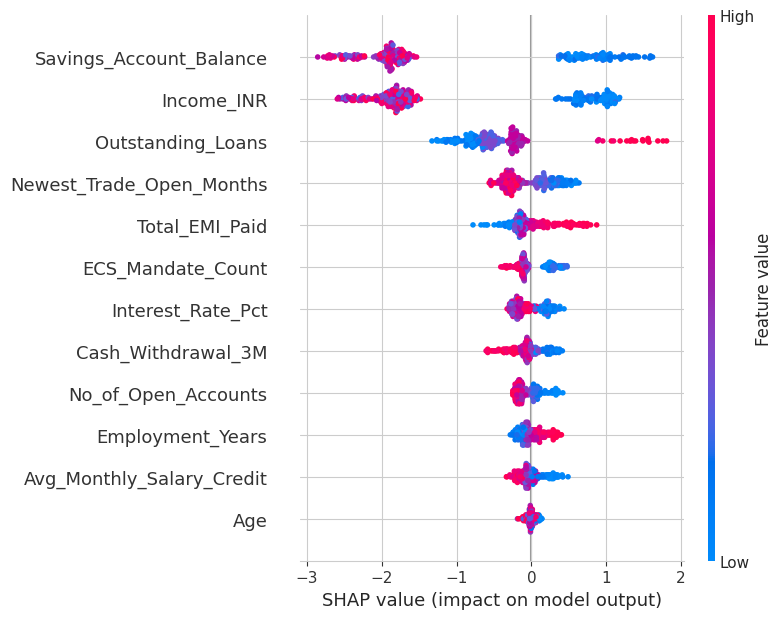

In [12]:
import pickle
with open('models/test_shap_values.pkl','rb') as f:
    shap_bundle = pickle.load(f)
import shap
shap.summary_plot(shap_bundle['shap_values'], shap_bundle['X_test'], show=False)
plt.tight_layout(); plt.show()

## Conclusion

See `reports/Model_Validation_Report.md` for the full write-up and
`notebooks/00_methodology_notes.md` for the overfitting investigation that
shaped the final variable list. Verdict: **Conditional Approval for Pilot**.